# Autoencoder

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/auduvignac/Deep-learning/blob/main/keras-basic/Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

## Introduction

Entraînement d'un autoencodeur sur le jeu de données FashionMNIST.

L'autencoder s'entraîne sur ses *embedings*.

## 📌 Entraînement d'un Autoencodeur sur ses *Embeddings*

Un **autoencodeur** (*autoencoder*) est un réseau de neurones utilisé pour l'apprentissage non supervisé. Il apprend à encoder les données en une représentation compressée (*embedding*), puis à reconstruire ces données à partir de cette représentation.

### 🔍 **1. Architecture d'un autoencodeur**

Un autoencodeur est composé de deux parties principales :

- **Encodeur** : Transforme l’entrée en une représentation de plus faible dimension (*embedding*).
- **Décodeur** : Reconstruit l’entrée originale à partir de l’*embedding*.

Le processus est illustré comme suit :

```plaintext
Entrée  →  Encodeur  →  Embedding  →  Décodeur  →  Sortie reconstruite
```

### 🎯 **2. Entraînement basé sur l'optimisation des *Embeddings***

- L’autoencodeur apprend à générer des *embeddings* qui capturent les caractéristiques essentielles des données.
- La **fonction de perte** (souvent l'erreur quadratique moyenne - MSE) mesure la différence entre l'entrée originale et la sortie reconstruite :

  $$ \mathcal{L} = || X - X' ||^2 $$

  où :
  - $X$ est l’entrée originale
  - $X'$ est la sortie reconstruite

- L’optimisation du réseau ajuste les poids pour améliorer la qualité des *embeddings* et minimiser la perte.

### 🚀 **3. Pourquoi entraîner un autoencodeur sur ses *Embeddings* ?**

Une fois entraîné, l'encodeur produit des *embeddings* utiles pour plusieurs tâches :

✅ **Réduction de dimensionnalité** : Comparable à PCA mais avec une approche non linéaire.

✅ **Détection d’anomalies** : Les anomalies ont des reconstructions de mauvaise qualité.

✅ **Apprentissage de représentations latentes** : Les *embeddings* peuvent être utilisés pour le clustering ou la classification.

De plus, un **second modèle** peut être entraîné sur ces *embeddings* pour des tâches spécifiques comme la reconnaissance de formes ou la génération de nouvelles données.

### 📌 **Exemple de code en PyTorch**

Voici un exemple d’autoencodeur simple en PyTorch :

```python
import torch
import torch.nn as nn
import torch.optim as optim

# Définition de l'Autoencodeur
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Instanciation du modèle
autoencoder = Autoencoder(input_dim=784, latent_dim=32)

# Définition de l'optimiseur et de la fonction de perte
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)
```

---

Cette approche permet d'apprendre des *embeddings* utiles tout en améliorant la reconstruction des données d'origine. 🚀

---

---

La figure ci-dessous illustre la structure d'un *autoencoder*

---

### Global Max Pooling 2D

### Conv2DTranspose


### UpSampling2D


- Plus proche voisin : Copie la valeur du pixel le plus proche ;
- Bilinéaire : Utilise tous les pixels voisins pour calculer la valeur du pixel, en utilisant des interpolations linéaires.

Dans l'API fonctionnelle, les modèles sont créés en spécifiant leurs entrées et sorties dans un graphe de couches. Cela signifie qu'un même graphe de couches peut être utilisé pour générer plusieurs modèles.

Dans l'exemple ci-dessous, nous utilisons la même pile de couches pour instancier deux modèles :
- Un modèle encodeur qui transforme des entrées d'images en vecteurs de 16 dimensions ;
- Un modèle autoencodeur de bout en bout destiné à l'entraînement.

```python
# Matrice 28x28
encoder_input = keras.Input(shape=(28, 28, 1), name='img')
x = layers.Conv2D(16, 3, activation='relu')(encoder_input)
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D(3)(x)
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.Conv2D(16, 3, activation='relu')(x)
# GlobalMaxPooling2D fournit un vecteur de taille 16
encoder_output = layers.GlobalMaxPooling2D()(x)
encoder = keras.Model(encoder_input, encoder_output, name='encoder')
encoder.summary()

# vecteur de taille 16 + Matrice 4x4
# Le Reshape peut être vu comme l'inverse du GlobalMaxPooling2D
# inverse du globalMaxPooling2D matrice 4x4 avec des 0 ailleurs
x = layers.Reshape((4, 4, 1))(encoder_output)
x = layers.Conv2DTranspose(16, 3, activation='relu')(x)
x = layers.Conv2DTranspose(32, 3, activation='relu')(x)
# UpSampling2D permet de reconstruire la matrice 24x24
x = layers.UpSampling2D(3)(x)
x = layers.Conv2DTranspose(16, 3, activation='relu')(x)
# Conv2DTranspose permet de reconstruire le vecteur d'entrée
# en utilisant des couches de convolution transposées
decoder_output = layers.Conv2DTranspose(1, 3, activation='relu')(x)
autoencoder = keras.Model(encoder_input, decoder_output, name='autoencoder')
autoencoder.summary()
```

```python
encoder_input = keras.Input(shape=(28, 28, 1), name='original_img')
x = layers.Conv2D(16, 3, activation='relu')(encoder_input)
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D(3)(x)
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.Conv2D(16, 3, activation='relu')(x)
encoder_output = layers.GlobalMaxPooling2D()(x)
encoder = keras.Model(encoder_input, encoder_output, name='encoder')
encoder.summary()

decoder_input = keras.Input(shape=(16,), name='encoded_img')
x = layers.Reshape((4, 4, 1))(decoder_input)
x = layers.Conv2DTranspose(16, 3, activation='relu')(x)
x = layers.Conv2DTranspose(32, 3, activation='relu')(x)
x = layers.UpSampling2D(3)(x)
x = layers.Conv2DTranspose(16, 3, activation='relu')(x)
decoder_output = layers.Conv2DTranspose(1, 3, activation='relu')(x)
decoder = keras.Model(decoder_input, decoder_output, name='decoder')
decoder.summary()
autoencoder_input = keras.Input(shape=(28, 28, 1), name='img')
encoded_img = encoder(autoencoder_input)
decoded_img = decoder(encoded_img)
autoencoder = keras.Model(autoencoder_input, decoded_img, name='autoencoder')
autoencoder.summary()
```

### Exercie : Entrainer un autoencodeur sur le jeu de données FashionMNIST

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ original_img (InputLayer)            │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 26, 26, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 6, 6, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 4, 4, 16)            │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling2d                 │ (None, 16)                  │               0 │
│ (GlobalMaxPooling2D)                 │                             │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,672 (72.94 KB)

 Trainable params: 18,672 (72.94 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ img (InputLayer)                     │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder (Functional)                 │ (None, 16)                  │          18,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder (Functional)                 │ (None, 28, 28, 1)           │           9,569 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 28,241 (110.32 KB)

 Trainable params: 28,241 (110.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 133s 270ms/step - loss: 0.0724 - val_loss: 0.0329
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 264ms/step - loss: 0.0318 - val_loss: 0.0294
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 127s 270ms/step - loss: 0.0289 - val_loss: 0.0276
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 146s 278ms/step - loss: 0.0272 - val_loss: 0.0265
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 265ms/step - loss: 0.0265 - val_loss: 0.0259
and the actual image looks like
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step


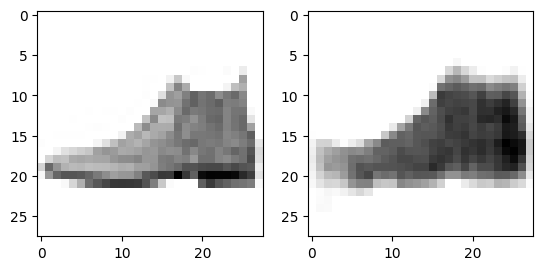

In [1]:
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import tensorflow as tf

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)


encoder_input = tf.keras.Input(shape=(28, 28, 1), name='original_img')
x = layers.Conv2D(16, 3, activation='relu')(encoder_input)
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D(3)(x)
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.Conv2D(16, 3, activation='relu')(x)
encoder_output = layers.GlobalMaxPooling2D()(x)
encoder = tf.keras.Model(encoder_input, encoder_output, name='encoder')
encoder.summary()

decoder_input = tf.keras.Input(shape=(16,), name='encoded_img')
x = layers.Reshape((4, 4, 1))(decoder_input)
x = layers.Conv2DTranspose(16, 3, activation='relu')(x)
x = layers.Conv2DTranspose(32, 3, activation='relu')(x)
x = layers.UpSampling2D(3)(x)
x = layers.Conv2DTranspose(16, 3, activation='relu')(x)
decoder_output = layers.Conv2DTranspose(1, 3, activation='relu')(x)
decoder = tf.keras.Model(decoder_input, decoder_output, name='decoder')
decoder.summary()

autoencoder_input = tf.keras.Input(shape=(28, 28, 1), name='img')
encoded_img = encoder(autoencoder_input)
decoded_img = decoder(encoded_img)
autoencoder = tf.keras.Model(autoencoder_input, decoded_img,
name='autoencoder')
autoencoder.summary()
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(train_images, train_images, epochs=5, batch_size=128,
shuffle=True, validation_data=(test_images, test_images))

print("and the actual image looks like")
img_out = autoencoder.predict(test_images[0].reshape(1,28,28,1))
f, axarr = plt.subplots(1,2)
axarr[0].imshow(test_images[0].reshape(28,28), cmap='Greys')
axarr[1].imshow(img_out.reshape(28,28), cmap='Greys')
plt.show()

# Exemple :
- Ajouter du bruit aux images de test et voir si l'autoencodeur peut les débruiter.
- Entraîner un autoencodeur pour débruiter des images.

In [ ]:
# Débruiter
import numpy as np

n = test_images.shape [0]
n_rows = test_images.shape [1]
n_cols = test_images.shape [2]
mean = 0.1
stddev = 0.05
noise = np.random.normal(mean, stddev, (n, n_rows, n_cols))
test_images_noisy = test_images + noise
img_out = autoencoder.predict(test_images_noisy [0].reshape(1,28,28,1))
f, axarr = plt.subplots(1,2)
axarr[0].imshow(test_images[0].reshape(28,28), cmap='Greys')
axarr[1].imshow(img_out.reshape(28,28), cmap='Greys')
plt.show()

# Entrainer pour le débruitage
import numpy as np

n = train_images.shape [0]
n_rows = train_images.shape [1]
n_cols = train_images.shape [2]
mean = 0.1
stddev = 0.05
noise = np.random.normal(mean, stddev, (n, n_rows, n_cols))
train_images_noisy = train_images + noise
autoencoder_input = tf.keras.Input(shape=(28, 28, 1), name='img')
encoded_img = encoder(autoencoder_input)
decoded_img = decoder(encoded_img)
autoencoder = tf.keras.Model(autoencoder_input, decoded_img, name='autoencoder')
autoencoder.summary()
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(train_images_noisy, train_images, epochs=5, batch_size=128, shuffle=True, validation_data=(test_images, test_images))

# Génération des images
mean = 0.5
stddev = 0.3
noise1 = np.random.normal(mean, stddev, (16,))
noise2 = np.random.normal(mean, stddev, (16,))
img_out1 = decoder.predict(noise1.reshape(1,16))
img_out2 = decoder.predict(noise2.reshape(1,16))
f, axarr = plt.subplots(1,2)
axarr[0].imshow(img_out1.reshape(28,28), cmap='Greys')
axarr[1].imshow(img_out2.reshape(28,28), cmap='Greys')
plt.show()